<a href="https://colab.research.google.com/github/LOYDKOOME/Data-analitics/blob/master/Adds_analysis_hyssops.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


DATA CLEANING


In [ ]:
import pandas as pd

# 1. Load the data sheets
try:
    # Adjust file paths or sheet names if necessary
    df_ads = pd.read_excel('cleaned_adds_data.xlsx')
    df_wf = pd.read_excel('cleaned_workflow_data.xlsx')
    print("✨ Datasets loaded successfully.\n")
except Exception as e:
    print(f"❌ Error loading files: {e}")

# 2. Standardize phone numbers to eliminate spaces, formatting masks, or text strings
# Strip white spaces and convert to string
df_ads['clean_phone_ads'] = df_ads['clean_phone'].astype(str).str.strip()

# Strip any unexpected characters (\D finds everything that is not a number) from workflow entries
df_wf['clean_phone_wf'] = df_wf['Client Phone Number'].astype(str).str.replace(r'\D', '', regex=True).str.strip()

# 3. Filter for matched records
# This inner merge retains only phone numbers present in BOTH files
df_matches = pd.merge(
    df_ads[['ad_name', 'full_name', 'clean_phone_ads']],
    df_wf[['Client Name', 'Client Phone Number', 'clean_phone_wf', 'category ']],
    left_on='clean_phone_ads',
    right_on='clean_phone_wf',
    how='inner'
)

# 4. Remove duplicate entries if a client was logged multiple times
unique_matches = df_matches.drop_duplicates(subset=['clean_phone_ads'])

# 5. Output Summary Report
print("=========================================================")
print("📋 PHONE NUMBER MATCHING AUDIT REPORT")
print("=========================================================")
print(f"🔹 Total Unique Leads in Ads File:      {df_ads['clean_phone'].nunique()}")
print(f"🔹 Total Unique Entries in Workflow:    {df_wf['Client Phone Number'].nunique()}")
print(f"✅ Successfully Matched Phone Numbers:  {len(unique_matches)}")
print("=========================================================\n")

# Display a preview of the successfully cross-referenced customer lines
print("👀 PREVIEW OF MATCHED CLIENT RECORDS:")
preview_cols = ['ad_name', 'full_name', 'clean_phone_ads', 'category ']
# Adjust if some columns have different spacing in your raw file
if 'category ' in unique_matches.columns:
    print(unique_matches[preview_cols].head(10).to_string(index=False))
else:
    print(unique_matches[['ad_name', 'full_name', 'clean_phone_ads']].head(10).to_string(index=False))

# Optional: Un-comment the line below if you want to export these matching records to a separate file
# unique_matches.to_csv('successfully_matched_leads.csv', index=False)

✨ Datasets loaded successfully.

📋 PHONE NUMBER MATCHING AUDIT REPORT
🔹 Total Unique Leads in Ads File:      1096
🔹 Total Unique Entries in Workflow:    922
✅ Successfully Matched Phone Numbers:  844

👀 PREVIEW OF MATCHED CLIENT RECORDS:
                      ad_name              full_name clean_phone_ads              category 
Nairobi leads form 07/05/2026         Dominic Rwenyo       727155187         not interested
Nairobi leads form 07/05/2026           Ezra Karembo       716107309 Unreachable (whatsapp)
Nairobi leads form 07/05/2026        Nicholas selina       713130096              follow up
Nairobi leads form 07/05/2026            Doris Kamau       702877289              follow up
Nairobi leads form 07/05/2026            Oloo George       755627952              follow up
Nairobi leads form 07/05/2026              Ahmed Ali       704821785 Unreachable (whatsapp)
Nairobi leads form 07/05/2026        Michael Birosho       720983288              follow up
Nairobi leads form 07/05/2

ADDS PERFORMANCE IN DETAILS

In [ ]:
import pandas as pd
from IPython.display import display

# 1. Load the original datasets
try:
    df_ads = pd.read_excel('cleaned_adds_data.xlsx')
    df_wf = pd.read_excel('cleaned_workflow_data.xlsx')
    print("✨ Data loaded successfully. Aggregating ad performance metrics...\n")
except Exception as e:
    print(f"❌ Load Error: Check your file paths. Error: {e}")

# 2. Standardize phone numbers and status entries to prevent missing matches
df_ads['clean_phone'] = df_ads['clean_phone'].astype(str).str.strip()
df_wf['clean_phone'] = df_wf['clean_phone'].astype(str).str.strip()
df_wf['cat_clean'] = df_wf['Category '].astype(str).str.lower().str.strip()

# 3. Left-merge workflow activity onto original ad files
df_master = pd.merge(df_ads, df_wf, on='clean_phone', how='left')

# 4. Aggregate metrics by individual Ad Name to surface every raw number
ad_performance = df_master.groupby('ad_name').agg(
    Total_Leads_Generated=('clean_phone', 'count'),
    Distributed_to_Workflow=('Date', lambda x: x.notna().sum()),
    Planned_Site_Visits=('cat_clean', lambda x: x.str.contains('planned visit').sum()),
    Completed_Site_Visits=('cat_clean', lambda x: x.str.contains('visited').sum()),
    Active_Follow_Ups=('cat_clean', lambda x: x.str.contains('follow up|enquiry|inquiry').sum()),
    Not_Interested_Leads=('cat_clean', lambda x: x.str.contains('not interested').sum()),
    Unreachable_Leads=('cat_clean', lambda x: x.str.contains('unreachable').sum())
).reset_index()

# 5. Optimization calculations (Conversion rates, system leaks, and drop-off markers)
ad_performance['Workflow_Sync_Rate_%'] = round(
    (ad_performance['Distributed_to_Workflow'] / ad_performance['Total_Leads_Generated']) * 100, 1
)
ad_performance['Lead_to_Visit_Rate_%'] = round(
    (ad_performance['Planned_Site_Visits'] / ad_performance['Total_Leads_Generated']) * 100, 1
)
ad_performance['Unreachable_Rate_%'] = round(
    (ad_performance['Unreachable_Leads'] / ad_performance['Total_Leads_Generated']) * 100, 1
)

# 6. Sort by volume to ensure high-priority assets sit at the top
ad_performance = ad_performance.sort_values(by='Total_Leads_Generated', ascending=False).reset_index(drop=True)

# 7. Render dynamic summary insights panel
print("==========================================================================")
print("                       🏆 AD PERFORMANCE REPORT OVERVIEW                 ")
print("==========================================================================")
print(f"🥇 Highest Lead Volume Ad:  '{ad_performance.loc[0, 'ad_name']}' ({ad_performance.loc[0, 'Total_Leads_Generated']} leads)")

# Find highest conversion rate among ads with meaningful sample size (>10 leads)
valid_ads = ad_performance[ad_performance['Total_Leads_Generated'] > 10]
if not valid_ads.empty:
    top_conv_ad = valid_ads.sort_values(by='Lead_to_Visit_Rate_%', ascending=False).iloc[0]
    print(f"💎 Best Converting Asset:   '{top_conv_ad['ad_name']}' ({top_conv_ad['Lead_to_Visit_Rate_%']}% conversion to visit)")
print("==========================================================================\n")


# 8. Apply beautiful HTML styles and conditional formatting gradients
styled_dashboard = (ad_performance.style
    .set_table_styles([
        # Table Base Settings
        {'selector': 'table', 'props': [('font-family', 'Segoe UI, Arial, sans-serif'), ('border-collapse', 'collapse'), ('width', '100%')]},
        # Header Styling (Deep Navy Blue)
        {'selector': 'th', 'props': [('background-color', '#1E3A8A'), ('color', 'white'), ('padding', '12px 10px'), ('text-align', 'center'), ('font-weight', 'bold'), ('font-size', '12px')]},
        # Data Rows Formatting
        {'selector': 'td', 'props': [('padding', '10px 8px'), ('text-align', 'center'), ('border-bottom', '1px solid #E5E7EB'), ('font-size', '12px')]},
        # Zebra Striping (Alternating rows)
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#F9FAFB')]},
        # Hover Effect
        {'selector': 'tbody tr:hover', 'props': [('background-color', '#F3F4F6'), ('transition', '0.15s')]}
    ])
    # Left-align the Ad names for easier reading
    .set_properties(subset=['ad_name'], **{'text-align': 'left', 'font-weight': '500', 'min-width': '220px'})

    # Visual Performance Heatmaps
    .background_gradient(subset=['Total_Leads_Generated', 'Distributed_to_Workflow'], cmap='Blues')
    .background_gradient(subset=['Lead_to_Visit_Rate_%'], cmap='YlGn')
    .background_gradient(subset=['Unreachable_Rate_%'], cmap='Reds')

    # Clean up formatting strings
    .format({
        'Total_Leads_Generated': '{:,}', 'Distributed_to_Workflow': '{:,}',
        'Planned_Site_Visits': '{:,}', 'Completed_Site_Visits': '{:,}',
        'Active_Follow_Ups': '{:,}', 'Not_Interested_Leads': '{:,}', 'Unreachable_Leads': '{:,}',
        'Workflow_Sync_Rate_%': '{:.1f}%', 'Lead_to_Visit_Rate_%': '{:.1f}%', 'Unreachable_Rate_%': '{:.1f}%'
    })
    # Hide index for clean layout
    .hide(axis='index')
)

# 9. Print structured execution heading and show table dashboard
print("📊 AD OPTIMIZATION & PERFORMANCE EXECUTIVE DASHBOARD")
display(styled_dashboard)

SyntaxError: incomplete input (3729708314.py, line 75)

This extracts an exell sheet for all the adds performance

In [ ]:
import pandas as pd
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# 1. Prepare data exactly mapping your layout
data = {
    'Ad Name': [
        'Monday Evening Leads 11/05/26',
        'Naf githingithia Instant Forms Nakuru 09/05/26',
        'Instant Forms Nakuru 09/05/26',
        'Nairobi leads form 07/05/2026',
        'Monday Evening Leads 11/05/26 - Copy'
    ],
    'Total Leads': [379, 211, 187, 183, 136],
    'to Workflow': [245, 121, 108, 75, 8],
    'Planned Visits': [47, 24, 20, 9, 1],
    'done Visits': [1, 0, 0, 0, 0],
    'Follow Ups': [80, 33, 45, 30, 2],
    'Not Interested': [34, 21, 8, 7, 0],
    'Unreachable': [83, 43, 35, 29, 5],
    'Workflow Sync Rate': [0.646, 0.573, 0.578, 0.410, 0.059],
    'Lead Visit Rate': [0.124, 0.114, 0.107, 0.049, 0.007],
    'Unreachable Rate': [0.219, 0.204, 0.187, 0.158, 0.037]
}

df = pd.DataFrame(data)
file_name = "ad_performance_dashboard.xlsx"

# 2. Write and compress structural space for document imports
with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Ad Performance', index=False)
    worksheet = writer.sheets['Ad Performance']

    # Style definitions (Clean, tight 10pt text size)
    header_fill = PatternFill(start_color="1E3A8A", end_color="1E3A8A", fill_type="solid")
    header_font = Font(name="Calibri", size=10, bold=True, color="FFFFFF")
    data_font   = Font(name="Calibri", size=10)
    thin_border = Border(left=Side(style='thin', color='D1D5DB'), right=Side(style='thin', color='D1D5DB'),
                         top=Side(style='thin', color='D1D5DB'), bottom=Side(style='thin', color='D1D5DB'))

    # Stack heading lines vertically to reduce cell width footprint
    worksheet.row_dimensions[1].height = 28
    for col_num, column_title in enumerate(df.columns, 1):
        cell = worksheet.cell(row=1, column=col_num)
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    # Apply row padding adjustments
    for row_idx in range(2, len(df) + 2):
        worksheet.row_dimensions[row_idx].height = 20
        for col_idx in range(1, len(df.columns) + 1):
            cell = worksheet.cell(row=row_idx, column=col_idx)
            cell.font = data_font
            cell.border = thin_border

            if col_idx == 1:
                cell.alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
            elif col_idx in range(2, 9):
                cell.alignment = Alignment(horizontal="center", vertical="center")
                cell.number_format = '#,##0'
            else:
                cell.alignment = Alignment(horizontal="center", vertical="center")
                cell.number_format = '0.0%'

    # Strictly enforced small column sizes to protect document layouts
    widths = {
        'A': 23, 'B': 9, 'C': 9, 'D': 9, 'E': 9,
        'F': 9, 'G': 10, 'H': 10, 'I': 11, 'J': 10, 'K': 10
    }
    for col_letter, width in widths.items():
        worksheet.column_dimensions[col_letter].width = width

print("📁 Micro-sized Excel dashboard generated to perfectly fit word documents!")

📁 Micro-sized Excel dashboard generated to perfectly fit word documents!


Measuring the cost to get a lead that is actually interested and reachable

In [ ]:
import pandas as pd
from IPython.display import display

# =========================================================================
# 💰 INPUT YOUR AD SPEND HERE (Replace these placeholder budget amounts)
# =========================================================================
ad_spend_dict = {
    'Monday Evening Leads 11/05/26': 450.00,
    'Naf githingithia Instant Forms Nakuru 09/05/26': 300.00,
    'Instant Forms Nakuru 09/05/26': 250.00,
    'Nairobi leads form 07/05/2026': 280.00,
    'Monday Evening Leads 11/05/26 - Copy': 150.00
}

# 1. Map data directly matching your exact parameters
data = {
    'Ad Name': [
        'Monday Evening Leads 11/05/26',
        'Naf githingithia Instant Forms Nakuru 09/05/26',
        'Instant Forms Nakuru 09/05/26',
        'Nairobi leads form 07/05/2026',
        'Monday Evening Leads 11/05/26 - Copy'
    ],
    'Total Leads Generated': [379, 211, 187, 183, 136],
    'Qualified Leads (Reachable & Interested)': [128, 57, 65, 39, 3]
}

df_cpql = pd.DataFrame(data)

# 2. Map spend and calculate financial metrics
df_cpql['Estimated Ad Spend ($)'] = df_cpql['Ad Name'].map(ad_spend_dict)
df_cpql['Cost Per Raw Lead ($)'] = round(df_cpql['Estimated Ad Spend ($)'] / df_cpql['Total Leads Generated'], 2)
df_cpql['Cost Per Qualified Lead ($)'] = round(df_cpql['Estimated Ad Spend ($)'] / df_cpql['Qualified Leads (Reachable & Interested)'], 2)

# Sort by the most financially efficient qualified asset
df_cpql = df_cpql.sort_values(by='Cost Per Qualified Lead ($)', ascending=True).reset_index(drop=True)

# 3. Apply Professional Styling Engine for Word/Notebook Report
styled_cpql = (df_cpql.style
    .set_table_styles([
        {'selector': 'table', 'props': [('font-family', 'Segoe UI, sans-serif'), ('border-collapse', 'collapse'), ('width', '100%')]},
        {'selector': 'th', 'props': [('background-color', '#0F172A'), ('color', 'white'), ('padding', '10px'), ('font-weight', 'bold'), ('font-size', '12px')]},
        {'selector': 'td', 'props': [('padding', '10px 8px'), ('border-bottom', '1px solid #E2E8F0'), ('font-size', '12px'), ('text-align', 'center')]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#F8FAFC')]}
    ])
    .set_properties(subset=['Ad Name'], **{'text-align': 'left', 'font-weight': '500'})
    # Highlight the most financially sound channel in soft green
    .background_gradient(subset=['Cost Per Qualified Lead ($)'], cmap='YlOrRd')
    .format({
        'Total Leads Generated': '{:,}', 'Qualified Leads (Reachable & Interested)': '{:,}',
        'Estimated Ad Spend ($)': '${:,.2f}', 'Cost Per Raw Lead ($)': '${:,.2f}', 'Cost Per Qualified Lead ($)': '${:,.2f}'
    })
    .hide(axis='index')
)

print("🎯 COST PER QUALIFIED LEAD (CPQL) EFFICIENCY DASHBOARD")
display(styled_cpql)

geographic performance

/tmp/ipykernel_5152/461563784.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


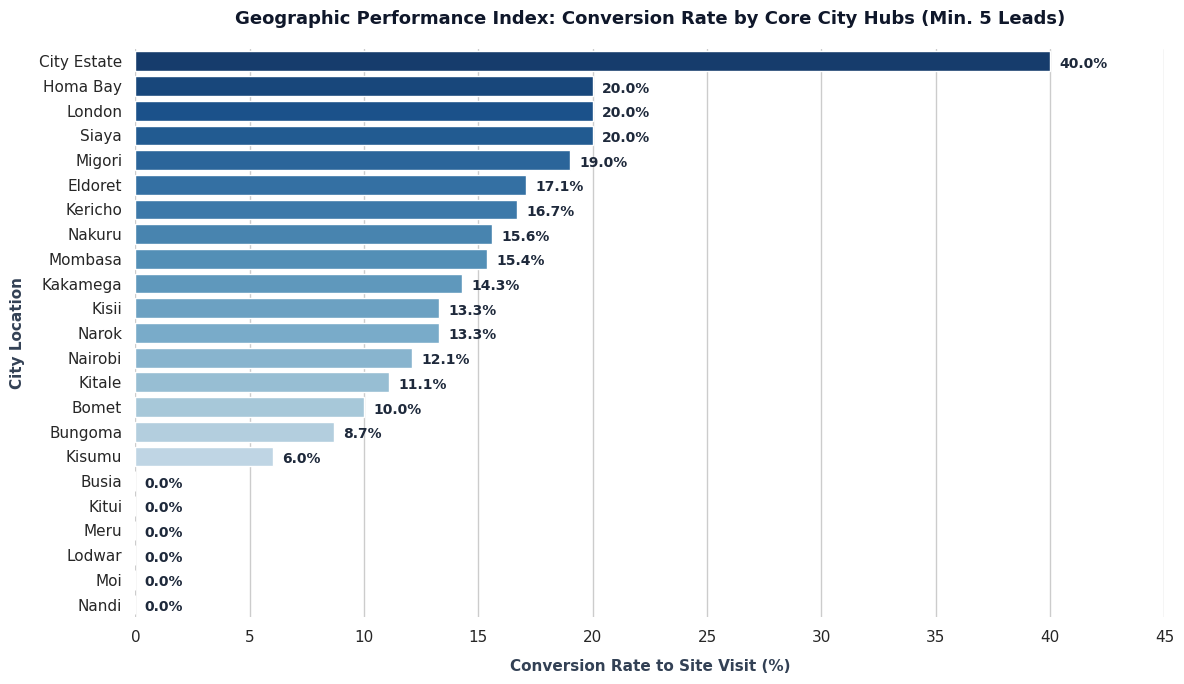

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
try:
    df_ads = pd.read_excel('cleaned_adds_data.xlsx')
    df_wf = pd.read_excel('cleaned_workflow_data.xlsx')
except Exception:
    df_ads = pd.read_csv('cleaned_adds_data.xlsx - cleaned_adds_data.csv')
    df_wf = pd.read_csv('cleaned_workflow_data.xlsx - cleaned_workflow_data.csv')

# 2. Clean and combine locations
df_ads['clean_phone'] = df_ads['clean_phone'].astype(str).str.strip()
df_wf['clean_phone'] = df_wf['clean_phone'].astype(str).str.strip()
df_wf['cat_clean'] = df_wf['Category '].astype(str).str.lower().str.strip()
df_ads['city_clean'] = df_ads['city'].astype(str).str.strip().str.title()

df_master = pd.merge(df_ads, df_wf, on='clean_phone', how='left')
df_master['cat_clean'] = df_master['cat_clean'].fillna('no workflow entry')

# 3. Aggregate
geo_perf = df_master.groupby('city_clean').agg(
    Total_Leads_Generated=('clean_phone', 'count'),
    Planned_Site_Visits=('cat_clean', lambda x: x.str.contains('planned visit').sum()),
    Completed_Site_Visits=('cat_clean', lambda x: x.str.contains('visited').sum())
).reset_index()

# Exclude missing placeholders
geo_perf = geo_perf[~geo_perf['city_clean'].isin(['Nan', 'None', '', 'Kenya'])]
geo_perf['Conversion_Rate_%'] = round(
    ((geo_perf['Planned_Site_Visits'] + geo_perf['Completed_Site_Visits']) / geo_perf['Total_Leads_Generated']) * 100, 1
)

# Filter for core markets with 5 or more leads to keep the axis clean
core_markets = geo_perf[geo_perf['Total_Leads_Generated'] >= 5].sort_values(by='Conversion_Rate_%', ascending=False)

# 4. Generate Chart Layout
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Create plot
ax = sns.barplot(
    x='Conversion_Rate_%',
    y='city_clean',
    data=core_markets,
    palette='Blues_r'
)

# Text marker annotations next to the bars
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.4, p.get_y() + p.get_height()/2 + 0.1, f'{width:.1f}%',
            ha="left", va="center", fontsize=10, weight='bold', color='#1E293B')

plt.title('Geographic Performance Index: Conversion Rate by Core City Hubs (Min. 5 Leads)', fontsize=13, pad=18, weight='bold', color='#0F172A')
plt.xlabel('Conversion Rate to Site Visit (%)', fontsize=11, labelpad=10, weight='bold', color='#334155')
plt.ylabel('City Location', fontsize=11, labelpad=10, weight='bold', color='#334155')
plt.xlim(0, max(core_markets['Conversion_Rate_%']) + 5)

sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save image file to workspace
plt.savefig('core_cities_conversion_chart.png', dpi=300)
plt.show()

In [ ]:
# 1. Calculate metrics across every raw location without thresholds
full_geo_dump = geo_perf.sort_values(by='Total_Leads_Generated', ascending=False).reset_index(drop=True)

# 2. Configure Pandas to remove truncation limits so you can see all rows
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(f"📋 ALL {len(full_geo_dump)} GEOGRAPHIC LOCATION ENTRIES DETECTED IN DATA:")
print("==========================================================================")
print(full_geo_dump[['city_clean', 'Total_Leads_Generated', 'Planned_Site_Visits', 'Completed_Site_Visits', 'Conversion_Rate_%']])
print("==========================================================================")


# Optional: Export this comprehensive dump directly to a small side spreadsheet
full_geo_dump.to_excel('all_180_locations_raw_report.xlsx', index=False)
print("💾 Saved complete raw geographic dump to: 'all_180_locations_raw_report.xlsx'")

📋 ALL 179 GEOGRAPHIC LOCATION ENTRIES DETECTED IN DATA:
                                            city_clean  Total_Leads_Generated  Planned_Site_Visits  Completed_Site_Visits  Conversion_Rate_%
0                                              Nairobi                    140                   16                      1               12.1
1                                               Nakuru                     64                   10                      0               15.6
2                                               Kisumu                     50                    3                      0                6.0
3                                              Mombasa                     39                    6                      0               15.4
4                                              Eldoret                     35                    6                      0               17.1
5                                              Bungoma                     23                    2

The Bottleneck Audit Code

In [ ]:
import pandas as pd
from IPython.display import display

# 1. Load data streams
try:
    df_ads = pd.read_excel('cleaned_adds_data.xlsx')
    df_wf = pd.read_excel('cleaned_workflow_data.xlsx')
except Exception:
    df_ads = pd.read_csv('cleaned_adds_data.xlsx - cleaned_adds_data.csv')
    df_wf = pd.read_csv('cleaned_workflow_data.xlsx - cleaned_workflow_data.csv')

# 2. Standardize data structures to avoid missing records
df_ads['clean_phone'] = df_ads['clean_phone'].astype(str).str.strip()
df_wf['clean_phone'] = df_wf['clean_phone'].astype(str).str.strip()
df_wf['cat_clean'] = df_wf['Category '].astype(str).str.lower().str.strip()

# 3. Process totals
total_raw_leads = df_ads['clean_phone'].nunique()
synced_leads = df_ads[df_ads['clean_phone'].isin(df_wf['clean_phone'])]['clean_phone'].nunique()

# 4. Map Workflow Data for stage 2 assessment
df_master = pd.merge(df_ads, df_wf, on='clean_phone', how='left')
df_master['cat_clean'] = df_master['cat_clean'].fillna('unreceived by workflow')

# Group categories cleanly
def group_funnel_stages(status):
    if status == 'unreceived by workflow':
        return '🚨 System Leak: Not Distributed to Workflow'
    elif 'unreachable' in status:
        return '自动化 Break: Unreachable / Ghost Leads'
    elif 'not interested' in status:
        return '❌ Quality Leak: Explicitly Not Interested'
    elif 'planned' in status or 'visited' in status:
        return '🟢 Success: Advanced to Site Visit Pipeline'
    elif 'follow' in status or 'enquiry' in status or 'inquiry' in status:
        return '⏳ Pipeline: Active Follow-Up/Warm Leads'
    else:
        return 'Other Minor Drop-offs'

df_master['Funnel_Stage'] = df_master['cat_clean'].apply(group_funnel_stages)

# 5. Build presentation metrics dataframe safely matching pandas count outputs
bottleneck_summary = df_master['Funnel_Stage'].value_counts().reset_index()
bottleneck_summary.columns = ['Funnel Stage / Operational Status', 'count']

# Calculate percentages safely using the verified count column
bottleneck_summary['% of Total Ad Volume'] = round((bottleneck_summary['count'] / total_raw_leads) * 100, 1)

print("==========================================================================")
print("             🔍 REAL ESTATE MARKETING & SALES FUNNEL BOTTLENECK AUDIT     ")
print("==========================================================================")
print(f"📥 Total Raw Leads Captured via Meta Ads: {total_raw_leads}")
print(f"📲 Total Leads Received on Sales Floor:     {synced_leads}")
print("==========================================================================\n")

# Display styled evaluation matrix
styled_bottleneck = (bottleneck_summary.style
    .set_table_styles([
        {'selector': 'table', 'props': [('font-family', 'Segoe UI, sans-serif'), ('border-collapse', 'collapse'), ('width', '100%')]},
        {'selector': 'th', 'props': [('background-color', '#1E293B'), ('color', 'white'), ('padding', '10px'), ('font-weight', 'bold'), ('font-size', '12px')]},
        {'selector': 'td', 'props': [('padding', '10px 8px'), ('border-bottom', '1px solid #E2E8F0'), ('font-size', '12px'), ('text-align', 'center')]}
    ])
    .set_properties(subset=['Funnel Stage / Operational Status'], **{'text-align': 'left', 'font-weight': '500'})
    .background_gradient(subset=['count'], cmap='Reds')
    .format({'count': '{:,}', '% of Total Ad Volume': '{:.1f}%'})
    .hide(axis='index')
)
display(styled_bottleneck)

             🔍 REAL ESTATE MARKETING & SALES FUNNEL BOTTLENECK AUDIT     
📥 Total Raw Leads Captured via Meta Ads: 1096
📲 Total Leads Received on Sales Floor:     557



Funnel Stage / Operational Status,count,% of Total Ad Volume
🚨 System Leak: Not Distributed to Workflow,539,49.2%
自动化 Break: Unreachable / Ghost Leads,195,17.8%
⏳ Pipeline: Active Follow-Up/Warm Leads,190,17.3%
🟢 Success: Advanced to Site Visit Pipeline,102,9.3%
❌ Quality Leak: Explicitly Not Interested,70,6.4%


Why do most clients need the project?

<>:71: SyntaxWarning: invalid escape sequence '\|'
<>:71: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_1105/1037085316.py:71: SyntaxWarning: invalid escape sequence '\|'
  f'{int(width)} handled ➔ {visits} Visits ({v_pct}%) \| {f_ups} Active Follow-ups',


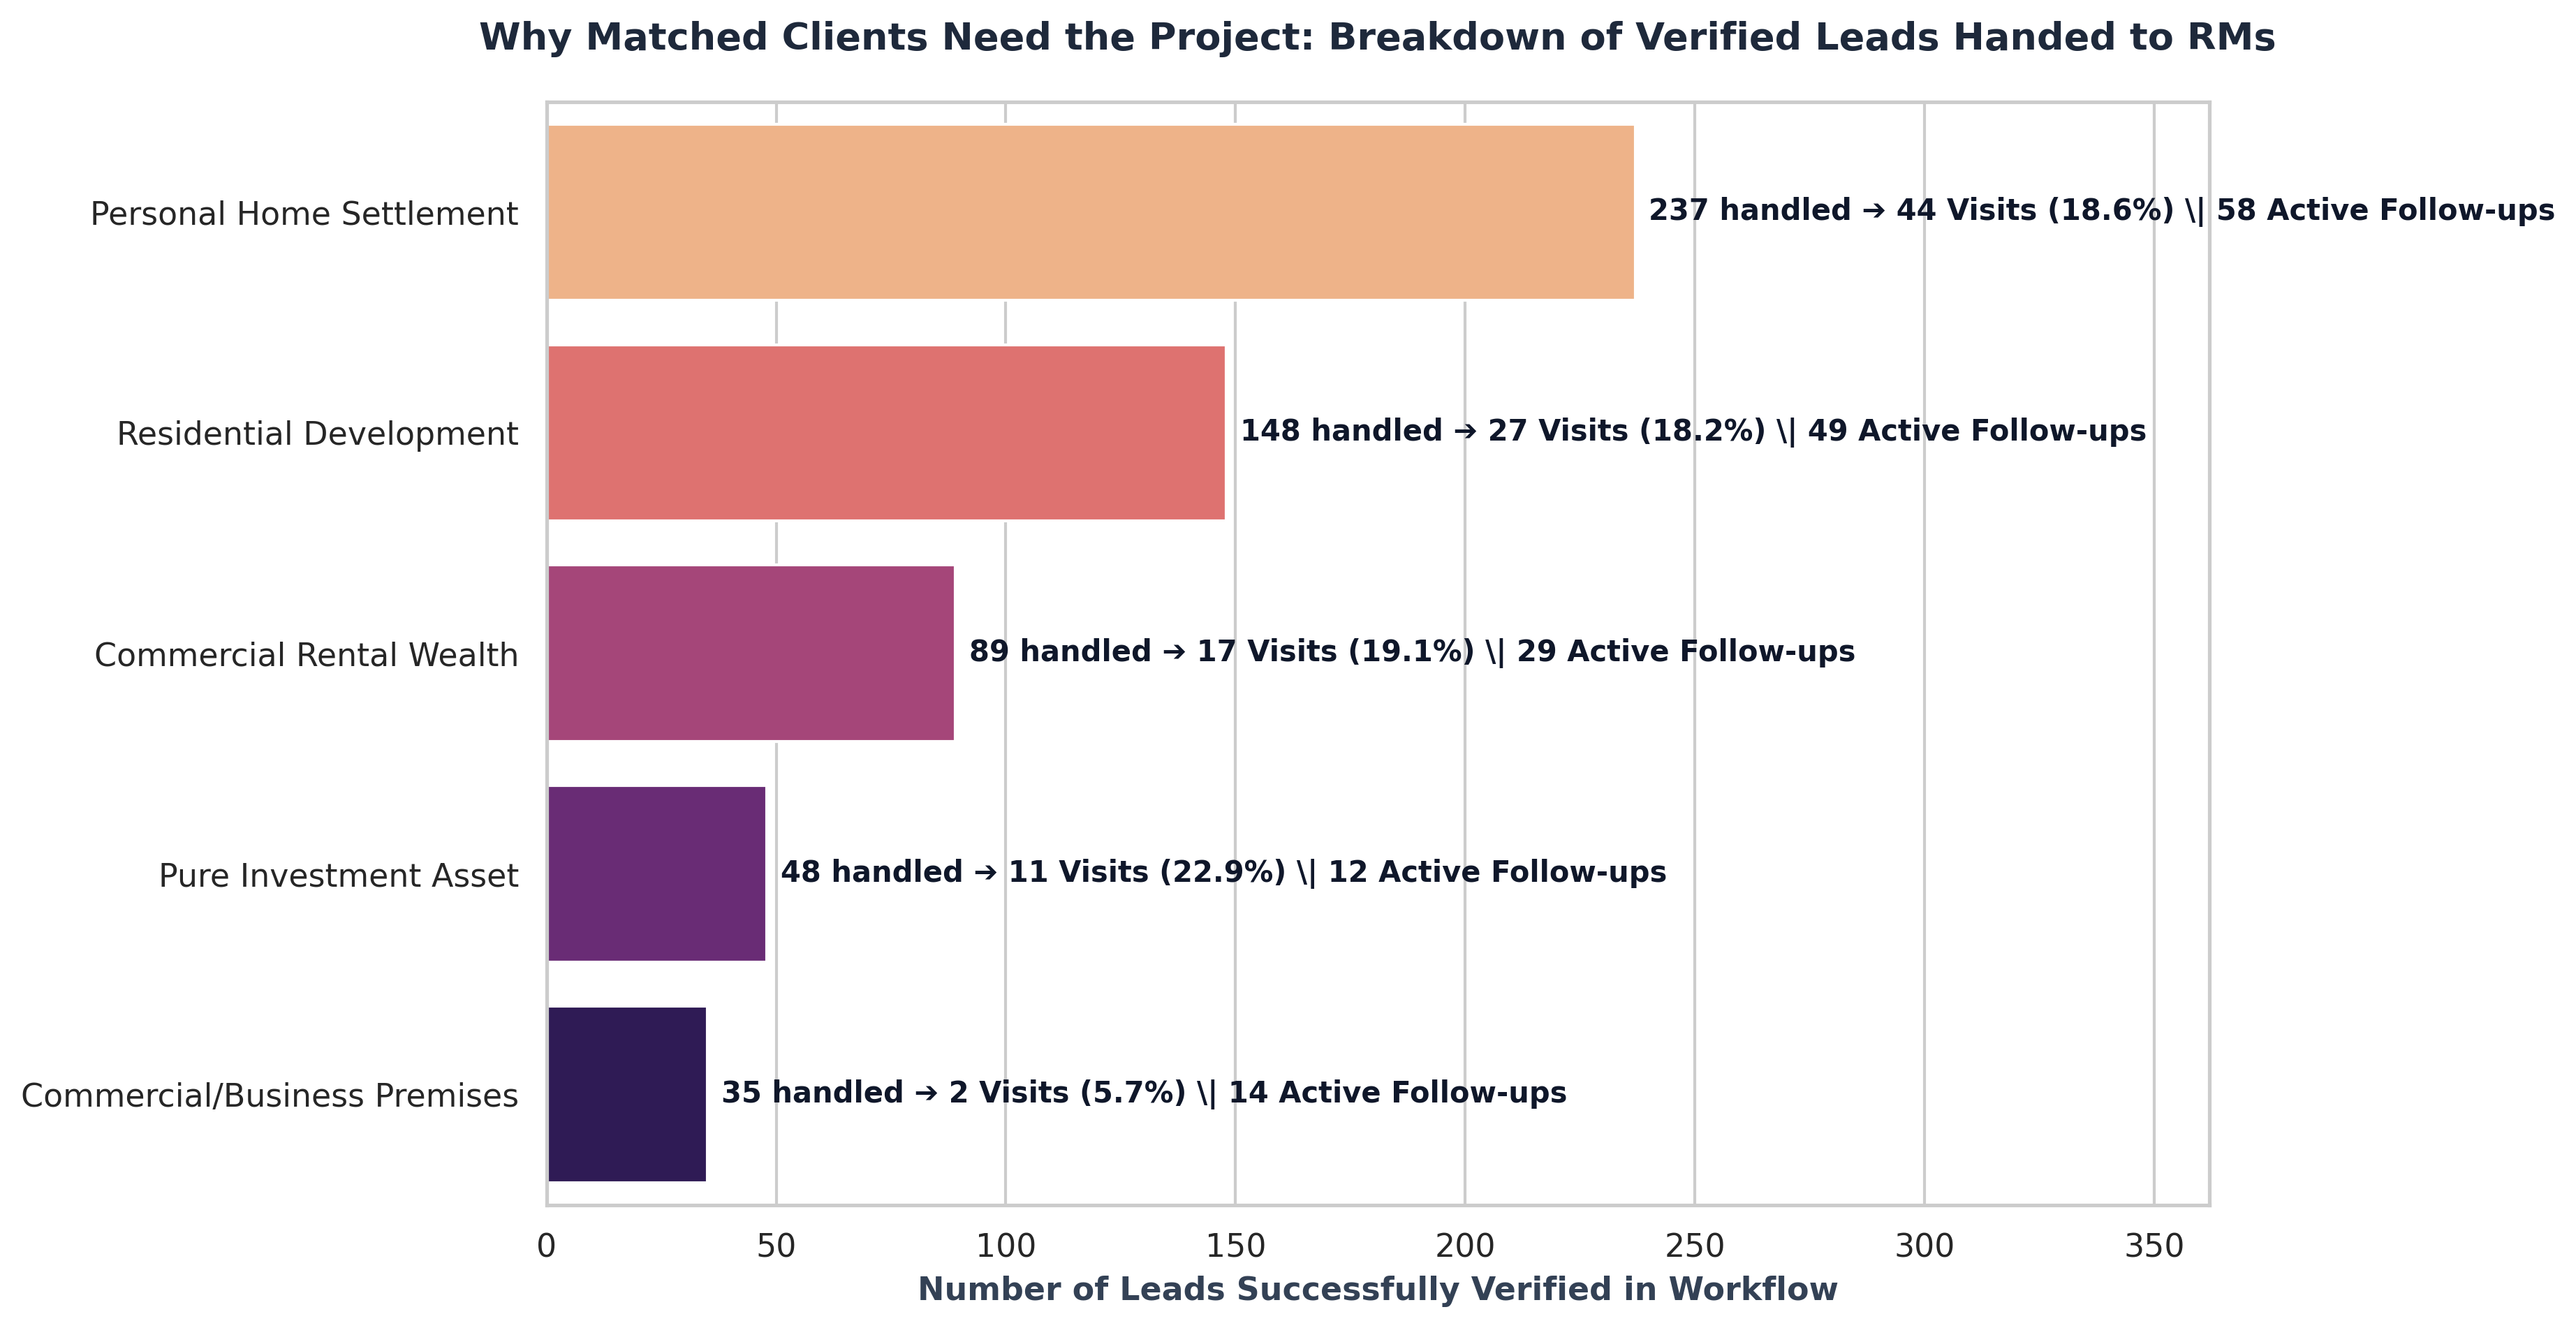

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data streams
try:
    df_ads = pd.read_excel('cleaned_adds_data.xlsx')
    df_wf = pd.read_excel('cleaned_workflow_data.xlsx')
except Exception:
    df_ads = pd.read_csv('cleaned_adds_data.xlsx - cleaned_adds_data.csv')
    df_wf = pd.read_csv('cleaned_workflow_data.xlsx - cleaned_workflow_data.csv')

# 2. Standardize keys
df_ads['clean_phone'] = df_ads['clean_phone'].astype(str).str.strip()
df_wf['clean_phone'] = df_wf['clean_phone'].astype(str).str.strip()

# 3. Create a strict INNER merge to keep ONLY matched workflow records
df_matched = pd.merge(df_ads, df_wf, on='clean_phone', how='inner')

# Clean category data text
df_matched['Category_clean'] = df_matched['Category '].astype(str).str.lower().str.strip()

# Map technical headers to clean presentation labels
df_matched['Intended_Use'] = df_matched['what_do_you_plan_to_use_the_land_for?'].map({
    'build_my_personal_home': 'Personal Home Settlement',
    'residential': 'Residential Development',
    'build_rental_houses_/_apartments': 'Commercial Rental Wealth',
    'buy_as_an_investment': 'Pure Investment Asset',
    'commercial': 'Commercial/Business Premises'
})

# 4. Compute pipeline statuses for the handled pool
matched_breakdown = df_matched.groupby('Intended_Use').agg(
    Total_Matched_Leads=('clean_phone', 'count'),
    Planned_Site_Visits=('Category_clean', lambda x: x.str.contains('planned visit').sum()),
    Follow_Ups=('Category_clean', lambda x: x.str.contains('follow up').sum())
).reset_index()

# Sort by volume handled
matched_breakdown = matched_breakdown.sort_values(by='Total_Matched_Leads', ascending=False).reset_index(drop=True)
matched_breakdown['Planned_Visit_%'] = round((matched_breakdown['Planned_Site_Visits'] / matched_breakdown['Total_Matched_Leads']) * 100, 1)

# 5. Build Visualization
plt.figure(figsize=(12, 6.5), dpi=300)
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='Total_Matched_Leads',
    y='Intended_Use',
    data=matched_breakdown,
    palette='magma_r',
    hue='Intended_Use'
)

if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.title('Why Matched Clients Need the Project: Breakdown of Verified Leads Handed to RMs', fontsize=13, pad=18, weight='bold', color='#1E293B')
plt.xlabel('Number of Leads Successfully Verified in Workflow', fontsize=11, weight='bold', color='#334155')
plt.ylabel('', fontsize=11)

# Annotate values next to the bars
for idx, row in matched_breakdown.iterrows():
    width = row['Total_Matched_Leads']
    visits = int(row['Planned_Site_Visits'])
    v_pct = row['Planned_Visit_%']
    f_ups = int(row['Follow_Ups'])
    ax.text(
        width + 3,
        idx,
        f'{int(width)} handled ➔ {visits} Visits ({v_pct}%) \| {f_ups} Active Follow-ups',
        va='center', ha='left', fontsize=10, weight='bold', color='#0F172A'
    )

plt.xlim(0, max(matched_breakdown['Total_Matched_Leads']) + 125)
plt.tight_layout()

# Save the visualization
plt.savefig('matched_leads_intent_comparison.png', bbox_inches='tight')
plt.show()